# Chapter 3 — Vectors, Part 2

## Learning Objectives

This notebook covers linear combinations, vector sets, span, subspace, linear independence, and basis.

## Theoretical Explanation

A linear weighted combination mixes vectors using scalar weights. The collection of all possible linear combinations forms the span of a vector set. If vectors provide redundant information, the set is linearly dependent. If no vector can be constructed from the others, the set is independent.

A basis is a linearly independent set that spans a space. In data science, basis vectors define how data is represented. PCA, ICA, SVD, and feature extraction can all be understood as finding useful basis vectors.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import norm, matrix_rank

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Linear Weighted Combination

In [2]:
v1 = np.array([1, 3])
v2 = np.array([2, 1])
weights = [2, -1]
combo = weights[0]*v1 + weights[1]*v2
print('v1:', v1)
print('v2:', v2)
print('linear combination:', combo)

A = np.column_stack([v1, v2])
w = np.array(weights)
print('matrix-vector equivalent:', A @ w)

v1: [1 3]
v2: [2 1]
linear combination: [0 5]
matrix-vector equivalent: [0 5]


### Output Interpretation

The manual weighted sum and matrix-vector multiplication produce the same result. This demonstrates why matrix-vector multiplication is the scalable implementation of linear combinations.

## 2. Linear Independence Through Rank

In [3]:
independent = np.column_stack([[1,0], [0,1]])
dependent = np.column_stack([[1,2], [2,4]])
print('rank independent matrix:', matrix_rank(independent))
print('rank dependent matrix:', matrix_rank(dependent))
print('independent columns?', matrix_rank(independent) == independent.shape[1])
print('dependent columns independent?', matrix_rank(dependent) == dependent.shape[1])

rank independent matrix: 2
rank dependent matrix: 1
independent columns? True
dependent columns independent? False


### Output Interpretation

The independent matrix has rank equal to the number of columns. The dependent matrix has lower rank because one column is a scalar multiple of the other.

## 3. Visualizing Span in 2D

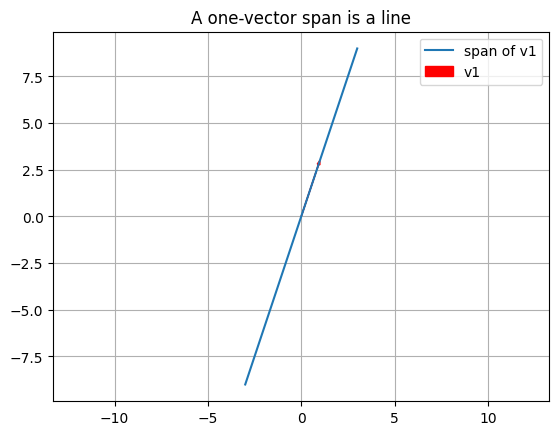

In [4]:
scalars = np.linspace(-3,3,50)
line_points = np.array([s*v1 for s in scalars])
plt.plot(line_points[:,0], line_points[:,1], label='span of v1')
plt.arrow(0,0,v1[0],v1[1],head_width=.15,color='red',length_includes_head=True,label='v1')
plt.axis('equal'); plt.grid(True); plt.legend(); plt.title('A one-vector span is a line')
plt.show()

### Output Interpretation

All scalar multiples of one nonzero vector form a line through the origin. This is a one-dimensional subspace embedded in two-dimensional space.

## Extended Study Notes

The central learning objective is not only to run code, but to connect the numerical result back to the linear algebra idea. In applied data science, vectors and matrices are not abstract objects only; they are the representation layer for observations, features, images, time series, model parameters, transformations, and decompositions.

A professional workflow should always include sanity checks. For example, reconstructed matrices should be compared with the original matrix, orthogonal matrices should be checked with `Q.T @ Q`, inverse computations should be checked against the identity matrix, and least-squares predictions should be inspected through residuals. These checks make the notebook academically stronger and reduce the risk of blindly trusting a black-box function.

## Chapter Summary

This notebook reproduces the core concept of the chapter using original/adapted Python examples. The code is intentionally compact but runnable, and the surrounding explanation focuses on conceptual understanding, interpretation, and practical relevance for data science.

## Key Takeaways

- Linear algebra concepts become clearer when formulas, geometry, and code are studied together.
- NumPy provides efficient implementations, but understanding the underlying math helps prevent misuse.
- Shape, rank, orientation, and numerical stability are recurring concerns in applied linear algebra.
- Every output should be interpreted as evidence of a mathematical property, not merely as a printed result.